# IN04: Agent Design Principles -- Single-Agent vs Multi-Agent


## Objectives

By the end of this notebook you will be able to:

- Describe the five components of an AI agent: planning, memory, state, tool calling, action
- Build a single-agent system for the Walmart Retail Assistant use case using LangGraph
- Identify the conditions under which single-agent design breaks down
- Design and build a multi-agent system with a coordinator and specialist sub-agents
- Apply a five-dimension scoring model to choose between single-agent and multi-agent

**Deliverable:** `agent_design_worksheet.txt`

In [ ]:
# For a Walmart Retail Assistant, should we use one AI agent to handle everything, or multiple specialised agents?

In [1]:
import os, json, time
from pathlib import Path
from dotenv import load_dotenv

from langchain_core.messages import HumanMessage, AIMessage, SystemMessage
from langchain_core.tools import tool
from langchain_openai import ChatOpenAI
from langgraph.graph import StateGraph, END
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode
from typing import TypedDict, Annotated

load_dotenv(override=True)
OPENAI_API_KEY = os.getenv('OPENAI_API_KEY')

llm = ChatOpenAI(model='gpt-4-turbo', api_key=OPENAI_API_KEY, temperature=0)
print('LLM ready:', llm.model_name)

/opt/homebrew/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


LLM ready: gpt-4-turbo


## Section 1: Agent Anatomy

An AI agent is not just an LLM call in a loop. It has five components that must each be designed deliberately.

| Component | What it does | Walmart Retail Assistant example |
|-----------|-------------|----------------------------------|
| **Planning** | Decides the sequence of steps to reach the goal | Break 'find cheapest milk near me' into: search -> inventory -> price compare -> respond |
| **Memory** | Retains conversation history and intermediate results | Remember customer said 'I prefer organic' earlier in the session |
| **State** | Tracks what has been done and what remains | `{query_resolved: False, products_found: 2, awaiting_inventory: True}` |
| **Tool Calling** | Invokes external functions or APIs | `check_inventory('GV-MILK-1G', 'STORE-042')` |
| **Action** | Generates the final output or triggers the next step | Return a structured JSON response or call the next tool |

**Production insight:** In LangGraph, state is the single source of truth.
Every node reads from state and writes back to state.
The graph topology (nodes + edges) encodes the planning logic explicitly.

## Section 2: Walmart Retail Tools

Four tools represent the external capabilities available to the Walmart Retail Assistant.
These same tools are reused in IN05 (orchestration patterns) and IN06 (failure handling).
In production each would call a real Walmart microservice via REST or MCP.

In [2]:
@tool
def search_product(query: str) -> str:
    """Search Walmart product catalog. Returns product name, price, aisle, and SKU."""
    catalog = {
        'milk':    'Great Value Whole Milk 1gal    | $3.98 | Aisle 12 | SKU: GV-MILK-1G',
        'bread':   'Great Value White Bread 20oz   | $1.28 | Aisle 8  | SKU: GV-BREAD-20',
        'eggs':    'Great Value Large Eggs 12ct    | $2.68 | Aisle 11 | SKU: GV-EGGS-12',
        'butter':  'Great Value Unsalted Butter 1lb| $4.48 | Aisle 12 | SKU: GV-BUTT-1',
        'chicken': 'Great Value Chicken Breast 3lb | $8.97 | Aisle 4  | SKU: GV-CHKN-3',
    }
    q = query.lower()
    for key, val in catalog.items():
        if key in q:
            return val
    return f'No product found for: {query}. Available: milk, bread, eggs, butter, chicken'


@tool
def check_inventory(sku: str) -> str:
    """Check real-time inventory for a product SKU at the nearest Walmart store."""
    inventory = {
        'GV-MILK-1G':   'In stock: 24 units | Store 042 Bentonville AR',
        'GV-BREAD-20':  'In stock: 61 units | Store 042 Bentonville AR',
        'GV-EGGS-12':   'Low stock: 5 units | Store 042 | Restock: Tomorrow',
        'GV-BUTT-1':    'In stock: 18 units | Store 042 Bentonville AR',
        'GV-CHKN-3':    'Out of stock | Store 042 | Available for online order',
    }
    return inventory.get(sku.upper(), f'SKU {sku} not found in inventory system')


@tool
def get_policy(policy_type: str) -> str:
    """Retrieve Walmart store policy. Types: returns, shipping, price_match, pickup, grocery."""
    policies = {
        'returns':     '90-day return policy. Receipt required. Electronics: 15 days.',
        'shipping':    'Free 2-day shipping on orders over $35. Same-day delivery in select areas.',
        'price_match': 'Walmart matches Amazon, Target, and major retailers on identical items.',
        'pickup':      'Free curbside pickup. Order by 6pm for same-day at most stores.',
        'grocery':     'Fresh guarantee: full refund on any fresh item if not satisfied.',
    }
    key = policy_type.lower().replace(' ', '_')
    for k, v in policies.items():
        if k in key or key in k:
            return v
    return f'Policy not found: {policy_type}. Available: returns, shipping, price_match, pickup, grocery'


@tool
def get_order_status(order_id: str) -> str:
    """Get current status of a Walmart order by order ID."""
    orders = {
        'WM-2024-001': 'Delivered June 28 2026 | 3 items | Total: $24.73',
        'WM-2024-002': 'Out for delivery | ETA: Today by 8pm',
        'WM-2024-003': 'Processing | Payment confirmed | Ships within 24 hours',
        'WM-2024-004': 'Cancelled | Refund of $18.45 issued June 27 2026',
    }
    return orders.get(order_id.upper(), f'Order {order_id} not found. Valid: WM-2024-001 to WM-2024-004')


WALMART_TOOLS = [search_product, check_inventory, get_policy, get_order_status]
print(f'{len(WALMART_TOOLS)} Walmart tools registered:')
for t in WALMART_TOOLS:
    print(f'  {t.name}: {t.description[:65]}')

4 Walmart tools registered:
  search_product: Search Walmart product catalog. Returns product name, price, aisl
  check_inventory: Check real-time inventory for a product SKU at the nearest Walmar
  get_policy: Retrieve Walmart store policy. Types: returns, shipping, price_ma
  get_order_status: Get current status of a Walmart order by order ID.


## Section 3: Single-Agent Design

One LLM handles planning, tool selection, and response generation.
The agent loop: LLM decides -> call tool -> observe result -> LLM decides again -> ... -> done.

**LangGraph graph topology:**
```
  [START]
     |
  [agent]  <----+
     |          |
  has tool_calls?
   YES |    NO |
 [tools]   [END]
     |
     +-----> back to [agent]
```

The `agent` node calls the LLM with all four tools bound.
The `tools` node executes every tool call the LLM requested in one pass.
This loop continues until the LLM emits a response with no tool calls.

In [8]:
# TypedDict - Defines what information the workflow state should contain.

class AgentState(TypedDict):
    messages: Annotated[list, add_messages]
    # Annotated - Allows additional behaviour to be attached to a field.

llm_with_tools = llm.bind_tools(WALMART_TOOLS)

SYSTEM_PROMPT = (
    'You are a Walmart Retail Assistant. Help customers find products, '
    'check inventory, understand store policies, and track orders. '
    'Always use the available tools to look up accurate information. '
    'Be concise and factual in your responses.'
)

def agent_node(state: AgentState) -> dict:
    messages = [SystemMessage(content=SYSTEM_PROMPT)] + state['messages']
    # For debugging, you can print the messages being sent to the LLM:
    # print("=="*40)
    # print('Invoking LLM with messages:')
    # for msg in messages:
    #     print(f'  {msg.type}: {msg.content}')
    # print("=="*40)
    response = llm_with_tools.invoke(messages)
    return {'messages': [response]}

def should_continue(state: AgentState) -> str:
    last = state['messages'][-1]
    if hasattr(last, 'tool_calls') and last.tool_calls:
        return 'tools'
    return END

single_graph = StateGraph(AgentState)
single_graph.add_node('agent', agent_node)
single_graph.add_node('tools', ToolNode(WALMART_TOOLS))
single_graph.set_entry_point('agent')
single_graph.add_conditional_edges('agent', should_continue, {'tools': 'tools', END: END})
single_graph.add_edge('tools', 'agent')
single_app = single_graph.compile()

print('Single-agent graph compiled.')
print('Nodes:', list(single_graph.nodes.keys()))

Single-agent graph compiled.
Nodes: ['agent', 'tools']


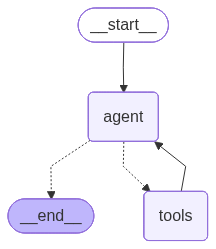

In [9]:
# To see the graph’s connection visually
from IPython.display import Image,display
display(Image(single_app.get_graph().draw_mermaid_png()))

In [10]:
TEST_QUERIES = [
    'What is the price of milk and is it in stock?',
    'I want to return a TV I bought 10 days ago -- what is the policy?',
    'Check my order WM-2024-002 please.',
    'Find chicken breast and check if it is available at the store.',
]

single_results = []
print('Running single-agent on Walmart queries...')
print('=' * 60)

for i, query in enumerate(TEST_QUERIES, 1):
    start = time.time()
    state = single_app.invoke({'messages': [HumanMessage(content=query)]})
    latency = round(time.time() - start, 2)
    final = state['messages'][-1].content
    tool_rounds = sum(1 for m in state['messages']
                      if hasattr(m, 'tool_calls') and m.tool_calls)
    single_results.append({
        'query': query, 'answer': final,
        'latency_sec': latency, 'tool_rounds': tool_rounds,
    })
    print(f'Q{i}: {query}')
    print(f'A : {final[:220]}')
    print(f'   Latency: {latency}s | Tool-call rounds: {tool_rounds}')
    print()

Running single-agent on Walmart queries...
Q1: What is the price of milk and is it in stock?
A : The Great Value Whole Milk (1 gallon) is priced at $3.98 and is available in Aisle 12. Currently, there are 24 units in stock at the Bentonville, AR store.
   Latency: 6.74s | Tool-call rounds: 2

Q2: I want to return a TV I bought 10 days ago -- what is the policy?
A : You can return the TV within 15 days of purchase, provided you have the receipt.
   Latency: 3.44s | Tool-call rounds: 1

Q3: Check my order WM-2024-002 please.
A : Your order with ID WM-2024-002 is currently out for delivery and is expected to arrive today by 8 PM.
   Latency: 2.47s | Tool-call rounds: 1

Q4: Find chicken breast and check if it is available at the store.
A : The Great Value Chicken Breast (3lb) is currently out of stock at your nearest store (Store 042). However, it is available for online order. You can find it in Aisle 4 when it is back in stock at the store.
   Latency: 6.88s | Tool-call rounds: 2



## Section 5: Multi-Agent Design -- Coordinator + Specialists

Split the single agent into a coordinator and two domain specialists.

```
Customer Query
      |
  [Coordinator]  -- classifies intent (PRODUCT vs SERVICE)
      |
  +---+---+
  |       |
[Product  [Service
 Agent]    Agent]
  |         |
  +----+----+
       |
    [END]
```

Each specialist has a smaller tool set and a tighter system prompt.
The coordinator adds ~100-200ms overhead but reduces per-agent context size
and enforces domain-level governance isolation.